# Divvy Bicycle Trip Analysis

This notebook analyzes the last 12 full months of Divvy trip data to identify user behavior patterns between member and casual riders.

## Business Task

The objective of this analysis is to understand how annual members and casual riders use Divvy bicycles differently. By identifying behavioral patterns in ride frequency, ride duration, and time-based usage, this project aims to generate insights that can support business and marketing decisions.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from dateutil.relativedelta import relativedelta
import requests
import zipfile
import io

In [6]:
today = pd.Timestamp.today().normalize()
first_day_current_month = today.replace(day=1)

months_12 = pd.date_range(
    start=first_day_current_month - pd.DateOffset(months=12),
    end=first_day_current_month - pd.DateOffset(months=1),
    freq="MS"
).strftime("%Y%m").tolist()

months_12

['202504',
 '202505',
 '202506',
 '202507',
 '202508',
 '202509',
 '202510',
 '202511',
 '202512',
 '202601',
 '202602',
 '202603']

In [7]:
zip_names = [f"{month}-divvy-tripdata.zip" for month in months_12]
base_url = "https://divvy-tripdata.s3.amazonaws.com/"
urls = [base_url + zip_name for zip_name in zip_names]

urls[:3]

['https://divvy-tripdata.s3.amazonaws.com/202504-divvy-tripdata.zip',
 'https://divvy-tripdata.s3.amazonaws.com/202505-divvy-tripdata.zip',
 'https://divvy-tripdata.s3.amazonaws.com/202506-divvy-tripdata.zip']

In [11]:
def read_divvy_zip(url):
    response = requests.get(url)
    response.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        csv_files = [
            name for name in z.namelist()
            if name.endswith(".csv") and not name.startswith("__MACOSX/")
        ]

        if len(csv_files) != 1:
            raise ValueError(f"Unexpected number of CSV files in {url}: {csv_files}")

        with z.open(csv_files[0]) as f:
            df = pd.read_csv(f)

    return df

In [12]:
df_list = []

for url in urls:
    print(f"Loading: {url}")
    df_month = read_divvy_zip(url)
    df_list.append(df_month)

divvy_12m = pd.concat(df_list, ignore_index=True)

Loading: https://divvy-tripdata.s3.amazonaws.com/202504-divvy-tripdata.zip
Loading: https://divvy-tripdata.s3.amazonaws.com/202505-divvy-tripdata.zip
Loading: https://divvy-tripdata.s3.amazonaws.com/202506-divvy-tripdata.zip
Loading: https://divvy-tripdata.s3.amazonaws.com/202507-divvy-tripdata.zip
Loading: https://divvy-tripdata.s3.amazonaws.com/202508-divvy-tripdata.zip
Loading: https://divvy-tripdata.s3.amazonaws.com/202509-divvy-tripdata.zip
Loading: https://divvy-tripdata.s3.amazonaws.com/202510-divvy-tripdata.zip
Loading: https://divvy-tripdata.s3.amazonaws.com/202511-divvy-tripdata.zip
Loading: https://divvy-tripdata.s3.amazonaws.com/202512-divvy-tripdata.zip
Loading: https://divvy-tripdata.s3.amazonaws.com/202601-divvy-tripdata.zip
Loading: https://divvy-tripdata.s3.amazonaws.com/202602-divvy-tripdata.zip
Loading: https://divvy-tripdata.s3.amazonaws.com/202603-divvy-tripdata.zip


In [13]:
divvy_12m.head()


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,AF3863596DF9D94B,classic_bike,2025-04-27 14:29:34.619,2025-04-27 14:36:23.584,Troy St & Elston Ave,15631,Richmond St & Diversey Ave,15645,41.945244,-87.706650,41.931902,-87.701195,member
1,8B38081EBE918800,electric_bike,2025-04-23 17:48:51.863,2025-04-23 17:59:06.015,Wabash Ave & Adams St,KA1503000015,Green St & Madison St,TA1307000120,41.879472,-87.625689,41.881859,-87.649264,member
2,1C7F1DE826BBBC8D,electric_bike,2025-04-05 17:55:30.845,2025-04-05 18:05:40.032,Damen Ave & Cortland St,13133,California Ave & Fletcher St,15642,41.915983,-87.677335,41.938429,-87.698008,member
3,CAD23D69A79A6C3B,classic_bike,2025-04-03 08:22:04.493,2025-04-03 08:32:06.099,Clark St & Elm St,TA1307000039,Orleans St & Merchandise Mart Plaza,TA1305000022,41.902973,-87.631280,41.888243,-87.636390,member
4,BE241E601482E0AB,electric_bike,2025-04-15 06:09:55.293,2025-04-15 06:19:58.942,Western Ave & Walton St,KA1504000103,Damen Ave & Charleston St,13288,41.898418,-87.686596,41.920082,-87.677855,member


In [14]:
divvy_12m.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5620544 entries, 0 to 5620543
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       object 
dtypes: float64(4), object(9)
memory usage: 557.5+ MB


In [15]:
divvy_12m["member_casual"].value_counts()

,count
member_casual,
member,3605045
casual,2015499


In [16]:
divvy_clean = divvy_12m.copy()

divvy_clean["started_at"] = pd.to_datetime(divvy_clean["started_at"], errors="coerce")
divvy_clean["ended_at"] = pd.to_datetime(divvy_clean["ended_at"], errors="coerce")

divvy_clean["ride_length_min"] = (
    (divvy_clean["ended_at"] - divvy_clean["started_at"]).dt.total_seconds() / 60
)

divvy_clean = divvy_clean[
    divvy_clean["started_at"].notna() &
    divvy_clean["ended_at"].notna() &
    (divvy_clean["ride_length_min"] > 0) &
    (divvy_clean["ride_length_min"] < 1440)
].copy()

In [17]:
divvy_feat = divvy_clean.copy()

divvy_feat["date"] = divvy_feat["started_at"].dt.date
divvy_feat["month"] = divvy_feat["started_at"].dt.strftime("%Y-%m")
divvy_feat["day_of_week"] = divvy_feat["started_at"].dt.day_name()
divvy_feat["hour"] = divvy_feat["started_at"].dt.hour

In [18]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

divvy_feat["day_of_week"] = pd.Categorical(
    divvy_feat["day_of_week"],
    categories=day_order,
    ordered=True
)

In [19]:
divvy_feat["member_casual"].value_counts()

,count
member_casual,
member,3604017
casual,2010719


In [20]:
divvy_feat.groupby("member_casual")["ride_length_min"].agg(["count", "mean", "median"])

,count,mean,median
member_casual,,,
casual,2010719,19.089139,11.33665
member,3604017,12.016988,8.58370


Casual riders take significantly longer rides on average, while members use the service more frequently but for shorter durations.

/tmp/ipykernel_9478/3374569416.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dow = divvy_feat.groupby(["member_casual", "day_of_week"]).size().reset_index(name="n")


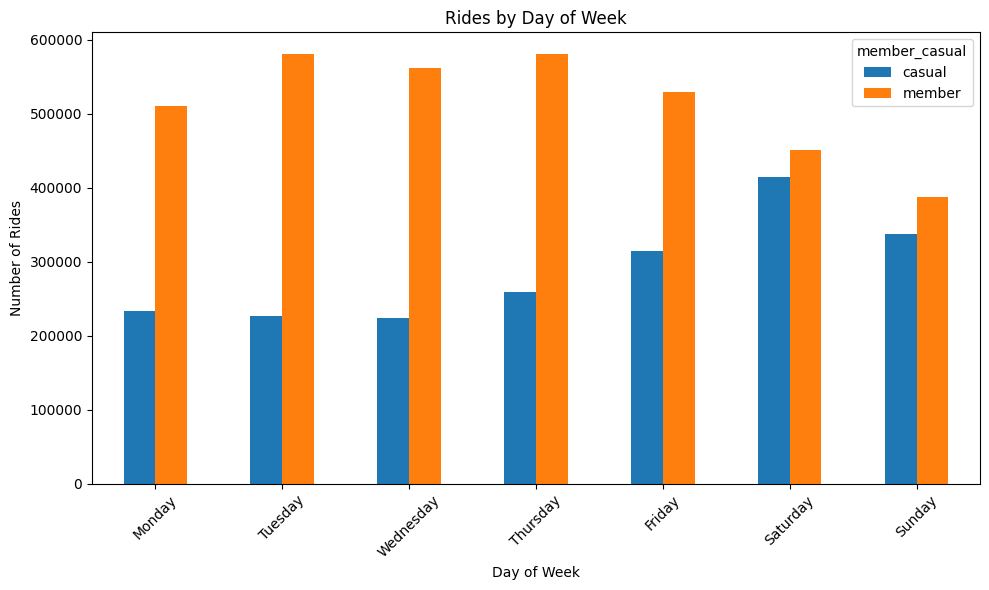

In [21]:
dow = divvy_feat.groupby(["member_casual", "day_of_week"]).size().reset_index(name="n")

pivot_dow = dow.pivot(index="day_of_week", columns="member_casual", values="n")

pivot_dow.plot(kind="bar", figsize=(10, 6))

plt.title("Rides by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Rides")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

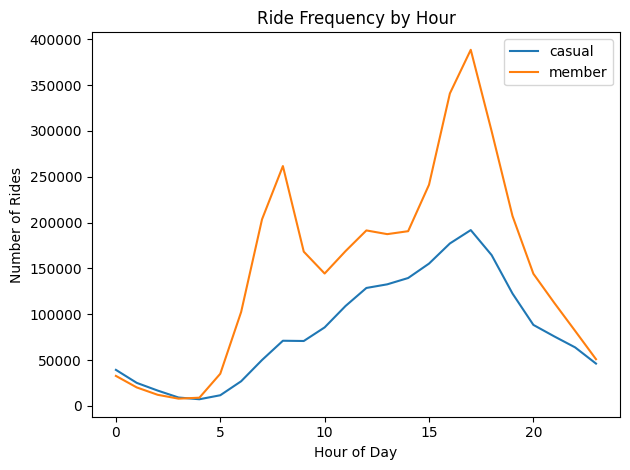

In [22]:
hourly = divvy_feat.groupby(["member_casual", "hour"]).size().reset_index(name="n")

for rider_type in hourly["member_casual"].unique():
    subset = hourly[hourly["member_casual"] == rider_type]
    plt.plot(subset["hour"], subset["n"], label=rider_type)

plt.title("Ride Frequency by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Rides")
plt.legend()
plt.tight_layout()
plt.show()

## Key Insights

- Annual members use the service significantly more frequently than casual riders, indicating regular and routine-based usage patterns.

- Casual riders tend to have longer ride durations on average, suggesting they are more likely to use the service for leisure or recreational purposes rather than commuting.

- Member activity is more concentrated on weekdays, while casual riders show increased usage on weekends, highlighting different usage behaviors between the two groups.

- Ride frequency varies throughout the day, with members showing peaks during typical commuting hours, whereas casual riders display more evenly distributed activity patterns.

- These differences suggest that casual riders represent a potential growth opportunity, particularly through targeted strategies aimed at converting them into annual members.

## Recommendations

- Develop targeted marketing campaigns aimed at converting casual riders into annual members, especially focusing on weekend users.

- Introduce incentives such as discounted memberships or trial periods for frequent casual riders.

- Optimize service availability and bike distribution during peak commuting hours to support member usage.

- Create promotional offers or packages tailored to leisure riders to gradually transition them into more regular users.